
# 🎓 Assignment: Reading and Visualizing Images in Python

**Course:** Introduction to Image Processing / Computer Vision  
**Level:** Undergraduate / Early Graduate  
**Format:** Jupyter Notebook  

---

## 📌 Learning Objectives
By the end of this assignment, students will be able to:

- Read images using different Python libraries
- Understand differences between image formats and data types
- Convert between color spaces
- Visualize and process images using NumPy-based tools

---

## 📝 Instructions

- Complete all **TODO** sections.
- Run each cell after writing your code.
- Add short comments explaining *what your code does*.
- Submit the completed notebook (`.ipynb`).



## 📦 Package Installation

**Run this cell FIRST** to install all required packages.


In [11]:

# Install required packages
# Run this cell once before starting the assignment

!pip install pillow numpy matplotlib scikit-image opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 MB 8.0 MB/s  0:00:06 eta 0:00:010:00:01m



## 🔹 Part 1: Using PIL (Pillow)

PIL loads images as **PIL Image objects**, not NumPy arrays.


Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (509, 339)
Image mode: RGB


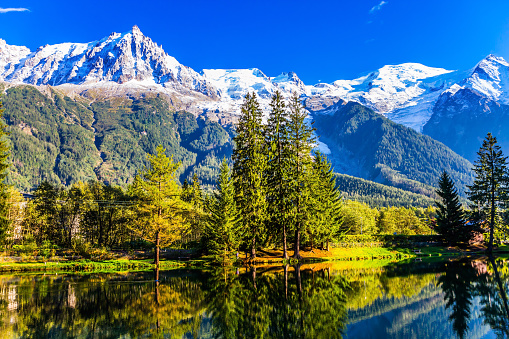

In [12]:

# TODO 1:
# 1. Open the image "images/test_image.jpg" using PIL
# 2. Print the image type, size, and mode
# 3. Display the image

from PIL import Image

# Open the image using PIL
img_pil = Image.open("test_image.jpg")

# Print image information
print(f"Image type: {type(img_pil)}")
print(f"Image size: {img_pil.size}")  # (width, height)
print(f"Image mode: {img_pil.mode}")  # RGB, L, RGBA, etc.

# Display the image
display(img_pil)



### ✨ Task 1.1: PIL → NumPy Conversion


In [13]:

# TODO 2:
# Convert the PIL image to a NumPy array
# Print the array shape and data type

import numpy as np

# Convert PIL image to NumPy array
img_array = np.array(img_pil)

# Print array properties
print(f"Array shape: {img_array.shape}")  # (height, width, channels)
print(f"Data type: {img_array.dtype}")    # typically uint8 (0-255)
print(f"Min value: {img_array.min()}, Max value: {img_array.max()}")


Array shape: (339, 509, 3)
Data type: uint8
Min value: 0, Max value: 255



## 🔹 Part 2: Matplotlib Image Reading

Matplotlib reads images directly as NumPy arrays.


Image shape: (339, 509, 3)
Data type: uint8


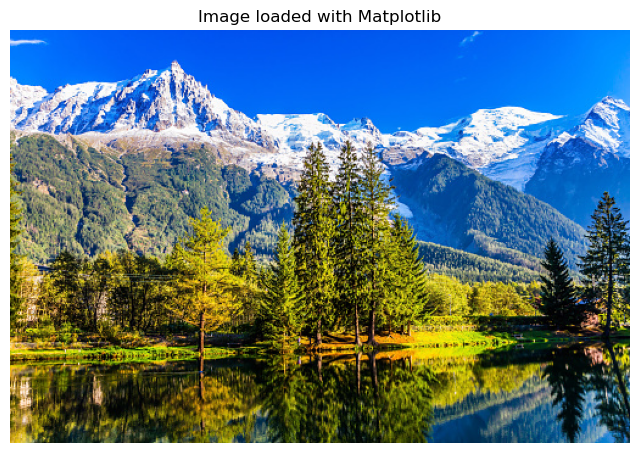

In [14]:

# TODO 3:
# 1. Read the image using matplotlib.image.imread
# 2. Print its shape
# 3. Display it using plt.imshow

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# Read the image - returns NumPy array directly
img_mpl = mpimg.imread("test_image.jpg")

# Print shape (height, width, channels)
print(f"Image shape: {img_mpl.shape}")
print(f"Data type: {img_mpl.dtype}")

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(img_mpl)
plt.title("Image loaded with Matplotlib")
plt.axis('off')  # Hide axes
plt.show()



### ❓ Concept Question
**Q:** Why does Matplotlib treat images as NumPy arrays?
Write your answer below.


**Answer:**

Matplotlib treats images as NumPy arrays because:

1. **Efficient numerical operations**: NumPy arrays allow fast mathematical operations on image pixels (e.g., filtering, transformations).
2. **Integration with scientific Python**: Matplotlib is designed for scientific visualization and works seamlessly with NumPy's n-dimensional array structure.
3. **Direct pixel manipulation**: Arrays provide direct access to pixel values for analysis and processing.
4. **Memory efficiency**: NumPy arrays are stored in contiguous memory blocks, making them faster than Python lists.
5. **Standardization**: Most scientific Python libraries (SciPy, scikit-image, etc.) use NumPy arrays as the standard data structure.


## 🔹 Part 3: scikit-image

scikit-image works with well-defined data ranges.


Original dtype: uint8
Float dtype: float64
Min pixel value: 0.0000
Max pixel value: 1.0000


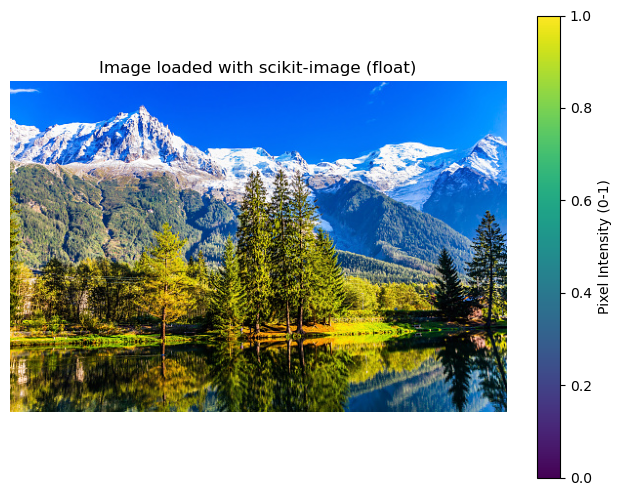

In [15]:

# TODO 4:
# 1. Read the image using skimage.io.imread
# 2. Convert it to float using img_as_float
# 3. Print min and max pixel values
# 4. Display the image

from skimage import io, img_as_float
import matplotlib.pyplot as plt

# Read the image using scikit-image
img_ski = io.imread("test_image.jpg")
print(f"Original dtype: {img_ski.dtype}")

# Convert to float (0.0 to 1.0 range)
img_float = img_as_float(img_ski)

# Print min and max values
print(f"Float dtype: {img_float.dtype}")
print(f"Min pixel value: {img_float.min():.4f}")
print(f"Max pixel value: {img_float.max():.4f}")

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(img_float)
plt.title("Image loaded with scikit-image (float)")
plt.axis('off')
plt.colorbar(label='Pixel Intensity (0-1)')
plt.show()



### ✨ Task 3.1: Data Type Exploration

**Q:** Why is using `astype(float)` discouraged compared to `img_as_float`?
Explain briefly.


**Answer:**

Using `astype(float)` is discouraged compared to `img_as_float` because:

1. **No rescaling**: `astype(float)` simply changes the data type without rescaling values. For example, uint8 values (0-255) become float values (0.0-255.0), not the normalized range (0.0-1.0).

2. **Loss of standardization**: `img_as_float` properly normalizes the image to the [0, 1] range, which is the standard in scikit-image and many image processing algorithms.

3. **Algorithm compatibility**: Many image processing functions expect images in the [0, 1] range. Using `astype(float)` without rescaling can cause unexpected results or errors.

Example:
```python
img = np.array([[255, 128]], dtype=np.uint8)
img.astype(float)       # Returns [[255.0, 128.0]] - WRONG range!
img_as_float(img)       # Returns [[1.0, 0.502]] - CORRECT range!
```


## 🔹 Part 4: OpenCV

⚠️ OpenCV loads color images in **BGR** format.


Grayscale shape: (339, 509)
BGR shape: (339, 509, 3)


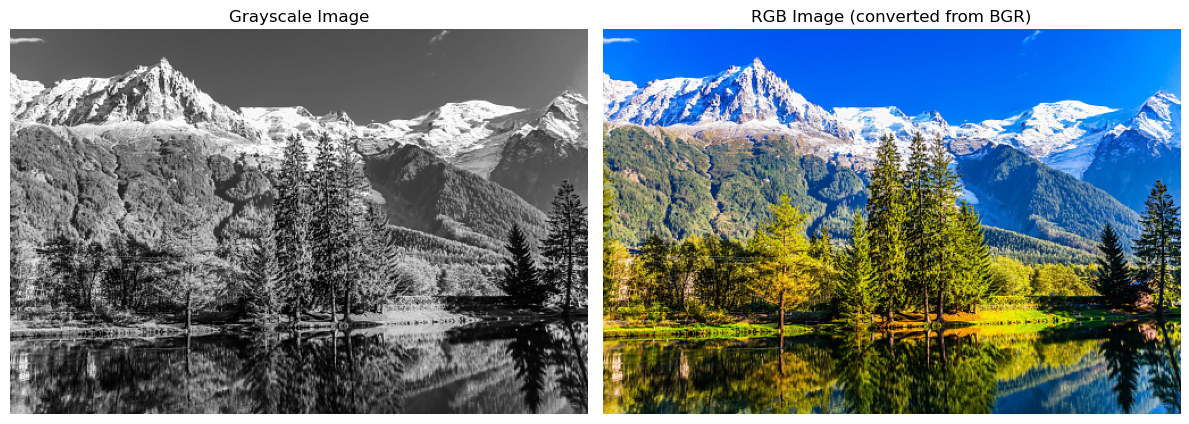

In [18]:
# TODO 5:
# 1. Read the image in grayscale and color using OpenCV
# 2. Convert the color image from BGR to RGB
# 3. Display the RGB image using matplotlib

import cv2
import matplotlib.pyplot as plt

# Read image in grayscale
img_gray = cv2.imread("test_image.jpg", cv2.IMREAD_GRAYSCALE)
print(f"Grayscale shape: {img_gray.shape}")

# Read image in color (BGR format by default)
img_bgr = cv2.imread("test_image.jpg", cv2.IMREAD_COLOR)
print(f"BGR shape: {img_bgr.shape}")

# Convert BGR to RGB for correct display in matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display both images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Display grayscale
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Grayscale Image')
axes[0].axis('off')

# Display RGB (converted from BGR)
axes[1].imshow(img_rgb)
axes[1].set_title('RGB Image (converted from BGR)')
axes[1].axis('off')

plt.tight_layout()
plt.show()



### ✨ Task 4.1: Image Processing

Apply **Canny edge detection** on the grayscale image and display the result.


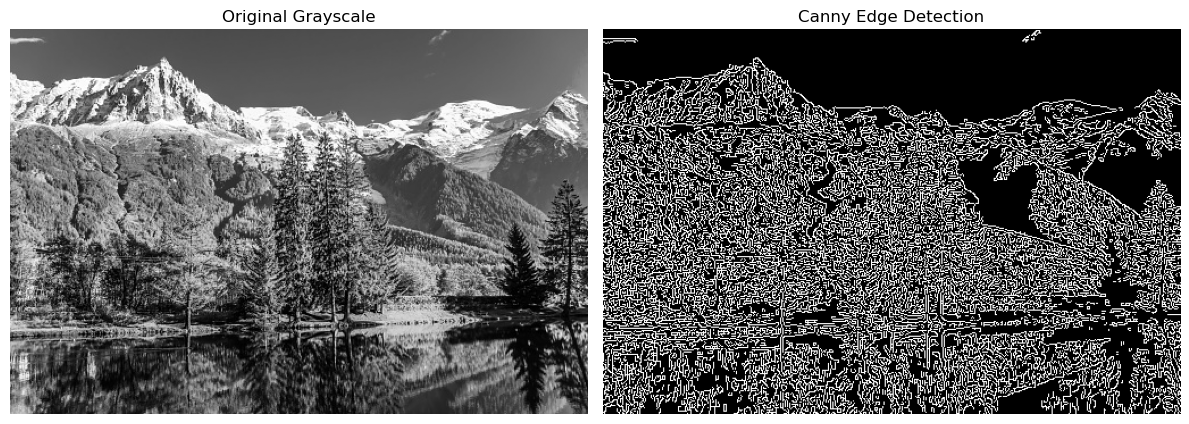

Edge pixels: 45141 (26.16% of total)


In [17]:

# TODO 6:
# Perform edge detection using cv2.Canny

# Apply Canny edge detection
# Parameters: image, lower_threshold, upper_threshold
edges = cv2.Canny(img_gray, threshold1=100, threshold2=200)

# Display original and edges side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original grayscale
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

# Edge detected image
axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edge Detection')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Print edge statistics
edge_pixels = np.count_nonzero(edges)
total_pixels = edges.size
print(f"Edge pixels: {edge_pixels} ({100*edge_pixels/total_pixels:.2f}% of total)")



## 🔹 Part 5: Advanced Formats (Optional Bonus)

These formats are common in **biomedical imaging**.



### ⭐ Bonus Task A: OME-TIFF

- Read an OME-TIFF file
- Print the image shape
- Inspect metadata


In [19]:

# BONUS (Optional)
# Uncomment and complete if the library and file are available

# Note: This requires the apeer-ometiff-library package
# Install with: pip install apeer-ometiff-library

# from apeer_ometiff_library import io

# # Read OME-TIFF file
# img_ome, omexml = io.read_ometiff("images/test_image.ome.tif")

# # Print image information
# print(f"Image shape: {img_ome.shape}")
# print(f"Data type: {img_ome.dtype}")

# # Display metadata (XML format)
# print("\nMetadata (first 500 chars):")
# print(omexml[:500])

# # If multi-dimensional (e.g., TZCYX), display one slice
# if len(img_ome.shape) > 2:
#     plt.imshow(img_ome[0, 0, 0], cmap='gray')  # First time, z, channel
#     plt.title('OME-TIFF Image - First Slice')
#     plt.axis('off')
#     plt.show()



### ⭐ Bonus Task B: Reading Multiple Images

Read all images from a folder and display them one by one.


In [20]:

# BONUS (Optional)

import glob
import cv2
import matplotlib.pyplot as plt
import os

# Path to image folder (adjust as needed)
path = "images/*.jpg"  # Read all JPG files

# Get all image files
image_files = glob.glob(path)
print(f"Found {len(image_files)} images")

# Calculate grid size for subplots
n_images = len(image_files)
if n_images > 0:
    cols = min(3, n_images)  # Max 3 columns
    rows = (n_images + cols - 1) // cols  # Ceiling division
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    # Flatten axes array for easier indexing
    if n_images > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    # Read and display each image
    for idx, file_path in enumerate(image_files):
        # Read image in BGR format
        img = cv2.imread(file_path)
        
        # Convert BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Display image
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(os.path.basename(file_path))
        axes[idx].axis('off')
    
    # Hide extra subplots if any
    for idx in range(n_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No images found in the specified path.")


Found 0 images
No images found in the specified path.



## 📊 Reflection Questions

1. Which library did you find easiest to use? Why?
2. Which library would you choose for real-time video processing?
3. What is the main difference between RGB and BGR?

Write short answers below.


**Reflection Answers:**

**1. Which library did you find easiest to use? Why?**

PIL (Pillow) is the easiest for basic tasks because it has a simple, intuitive API. For example, `Image.open()` and `.show()` are very straightforward. However, for scientific work, Matplotlib is also easy since it returns NumPy arrays directly, making it seamless to perform numerical operations. The choice depends on the use case: PIL for simple image manipulation, Matplotlib/scikit-image for scientific analysis.

**2. Which library would you choose for real-time video processing?**

**OpenCV** is the best choice for real-time video processing because:
- It's optimized for speed (written in C++)
- Has built-in video capture and processing functions
- Includes many optimized computer vision algorithms (face detection, object tracking, etc.)
- Supports GPU acceleration
- Can handle video streams efficiently with `cv2.VideoCapture()`

**3. What is the main difference between RGB and BGR?**

The main difference is the **order of color channels**:
- **RGB**: Red-Green-Blue (standard in most image formats and libraries)
- **BGR**: Blue-Green-Red (used by OpenCV)

For example, a pure red pixel:
- RGB: (255, 0, 0)
- BGR: (0, 0, 255)

This is why we must convert BGR to RGB when displaying OpenCV images with Matplotlib, otherwise colors appear incorrect (blue appears red and vice versa). OpenCV uses BGR for historical reasons related to early camera hardware conventions.